##### Feladat (Példatár 1.3)

A $C$ végkeresztmetszet és a fal közötti hézag $0.15 ~\mathrm{mm}$  az alábbi feladatnál látható hengeres tömör rudakból álló szerkezetnél a terheletlen állapotban. A terhelés nagysága $P = 300 ~\mathrm{kN}$ . Határozzuk meg a falakban ébredő reakcióerőket a terhelés alkalmazásakor. Mekkora az egyes részek hosszváltozása és bennük ébredő feszültség? Az anyag rugalmassági modulusza $70 ~\mathrm{GPa}$ .

<img src="img/01.jpg" alt="Feladat" width=350px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
L_1 = 600 # mm
L_2 = 600 # mm
L_3 = 0.15 # mm
d_1 = 50 # mm
d_2 = 25 # mm
P = 300 # kN
E = 70 # GPa

# Átváltás N, mm, MPa rendszerbe
P = P*10**3 # N
E = E*10**3 # MPa

#### I. Felteszzük, hogy a $C$ pont nem ér a $D$ ponthoz

##### Szabadtest ábra

<img src="img/02.jpg" alt="Feladat" width=250px>

##### Ismeretlen erővektor

In [3]:
A_x = sp.Symbol('A_x')

##### Erőegyensúly

In [4]:
# x irány
eq = A_x + P 

A_xsol = sp.solve(eq, A_x)[0]
display(Math(rf'A_x = {latex(A_xsol)} ~\mathrm{{N}}'))

<IPython.core.display.Math object>

##### Normál igénybevétel

In [5]:
N_1 = -A_xsol
display(Math(rf'N_1 = {latex(N_1)} ~\mathrm{{N}}'))

N_2 = -A_xsol - P
display(Math(rf'N_2 = {latex(N_2)} ~\mathrm{{N}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

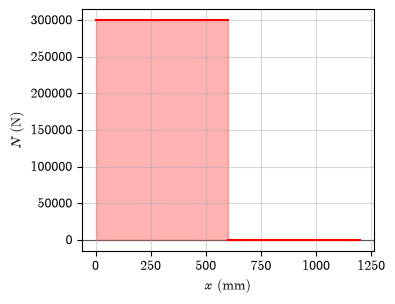

In [6]:
L_1n = float(L_1)
L_2n = float(L_2)
N_1n = float(N_1)
N_2n = float(N_2)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot([0, L_1n], [N_1n, N_1n], color='red')
plt.fill_between([0, L_1n], [N_1n, N_1n], 0, color='red', alpha=0.3)
plt.plot([L_1n, L_1n+L_2n], [N_2n, N_2n], color='red')
plt.fill_between([L_1n, L_1n+L_2n], [N_2n, N_2n], 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8, zorder=-1)
plt.xlabel(r'$x ~ \mathrm{(mm)}$')
plt.ylabel(r'$N ~ \mathrm{(N)}$')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('normal_igenybevetel_I.pdf')

##### A végkeresztmetszet elmozdulása

In [7]:
# A keresztmetszetek mérete
A_1 = d_1**2*sp.pi/4
A_2 = d_2**2*sp.pi/4

# A végkeresztmetszet elmozdulása
deltaL = (N_1*L_1) / (A_1*E) + (N_2*L_2) / (A_2*E) 
display(Math(rf'\Delta L = \frac{{N_1 L_1}}{{A_1 E}} + \frac{{N_2 L_2}}{{A_2 E}}  = {latex(deltaL.evalf(4))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

Mivel $\Delta L = 1.31$ mm $>$ $L_3 = 0.15$ mm, ezért a feltételezés hibás volt, $C$ pont hozzáér $D$ ponthoz a terhelés során. Oldajuk meg újra a feladatot, ezzel az információval.

#### II. A $C$ pont hozzáér a $D$ ponthoz

##### Szabadtest ábra

<img src="img/03.jpg" alt="Feladat" width=300px>

##### Ismeretlen erővektor

In [8]:
A_x, C_x = sp.symbols('A_x, C_x')

##### Normál igénybevétel

In [9]:
N_1 = -A_x
display(Math(rf'N_1 = {latex(N_1)}'))

N_2 = -A_x - P
display(Math(rf'N_2 = {latex(N_2)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Erőegyensúly

In [10]:
# x irány
eq1 = A_x + P + C_x 

# alakváltozási feltétel
delta_L1 = (N_1*L_1) / (A_1*E)
delta_L2 = (N_2*L_2) / (A_2*E)

eq2 = delta_L1 + delta_L2 - L_3

# Rendszer megoldása
sol = sp.solve([eq1, eq2], (A_x, C_x))
A_xsol = sol[A_x]
C_xsol = sol[C_x]

display(Math(rf'A_x = {latex(round(A_xsol, 3))} ~\mathrm{{N}}'))
display(Math(rf'C_x = {latex(round(C_xsol, 3))} ~\mathrm{{N}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Normál igénybevétel

In [11]:
N_1 = -A_xsol
display(Math(rf'N_1 = {latex(round(N_1, 3))} ~\mathrm{{N}}'))

N_2 = -A_xsol - P
display(Math(rf'N_2 = {latex(round(N_2, 3))} ~\mathrm{{N}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

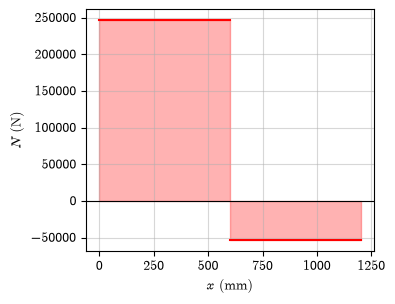

In [12]:
L_1n = float(L_1)
L_2n = float(L_2)
N_1n = float(N_1)
N_2n = float(N_2)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot([0, L_1n], [N_1n, N_1n], color='red')
plt.fill_between([0, L_1n], [N_1n, N_1n], 0, color='red', alpha=0.3)
plt.plot([L_1n, L_1n+L_2n], [N_2n, N_2n], color='red')
plt.fill_between([L_1n, L_1n+L_2n], [N_2n, N_2n], 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8, zorder=11)
plt.xlabel(r'$x ~ \mathrm{(mm)}$')
plt.ylabel(r'$N ~ \mathrm{(N)}$')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('normal_igenybevetel_II.pdf')

##### A végkeresztmetszet elmozdulása

In [13]:
# A keresztmetszetek mérete
A_1 = d_1**2*sp.pi/4
A_2 = d_2**2*sp.pi/4

# A részek hosszváltozása
deltaL1 = (N_1*L_1) / (A_1*E)
deltaL2 = (N_2*L_2) / (A_2*E) 

display(Math(rf'\Delta L_1 = \frac{{N_1 L_1}}{{A_1 E}} = {latex(deltaL1.evalf(4))} ~\mathrm{{mm}}'))
display(Math(rf'\Delta L_2= \frac{{N_2 L_2}}{{A_2 E}} = {latex(deltaL2.evalf(4))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### A részekben ébredő feszültségek

In [14]:
sigma_1 = N_1 / A_1
display(Math(rf'\sigma_1 = {latex(sigma_1.evalf(4))} ~\mathrm{{MPa}}'))

sigma_2 = N_2 / A_2
display(Math(rf'\sigma_2 = {latex(sigma_2.evalf(4))} ~\mathrm{{MPa}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>